# Week 5 - Embedding Space Exploration & COCO-Grounded Direction Vectors

**Literature:**
- Liu et al. (2023) LLaVA - https://arxiv.org/abs/2304.08485
- Alayrac et al. (2022) Flamingo - https://arxiv.org/abs/2204.14198
- Radford et al. (2021) CLIP - https://arxiv.org/abs/2103.00020

In [ ]:
# CELL 1 - Mount Drive

from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [ ]:
# CELL 2 - Install packages

!pip install -q --upgrade accelerate scikit-learn
!pip install -q sentencepiece
import transformers
print(f'transformers: {transformers.__version__}')
print('Ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 112.6 MB/s eta 0:00:00
transformers: 5.13.1
Ready.


In [ ]:
# CELL 3 - Paths

import os

BASE           = '/content/drive/MyDrive/dissertation_final'
PROCESSED_DIR  = f'{BASE}/data/processed'
COCO_INST_FILE = f'{BASE}/data/coco/annotations/instances_val2017.json'
RESULTS_DIR    = f'{BASE}/results'
STEER_STRENGTH = 0.3

os.makedirs(RESULTS_DIR, exist_ok=True)

print('Required files check:')
for f in [f'{PROCESSED_DIR}/test.csv', f'{RESULTS_DIR}/week3_baseline.csv']:
    ok = os.path.exists(f)
    print(f'  {"OK" if ok else "MISSING"} : {os.path.basename(f)}')
print('Proceed to Cell 4.')

Required files check:
  OK : test.csv
  OK : week3_baseline.csv
Proceed to Cell 4.


In [ ]:
# CELL 4 - Imports

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm import tqdm
from collections import defaultdict
from sklearn.manifold import TSNE
from transformers import CLIPProcessor, CLIPModel

print('All imports done.')

All imports done.


In [ ]:
# CELL 5  Load CLIP

CLIP_MODEL_ID = 'openai/clip-vit-base-patch32'
print(f'Loading CLIP: {CLIP_MODEL_ID}')
clip_proc  = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID)
dev        = 'cuda' if torch.cuda.is_available() else 'cpu'
clip_model = clip_model.to(dev).eval()
print(f'CLIP loaded on {dev}.')

Loading CLIP: openai/clip-vit-base-patch32


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

CLIP loaded on cuda.


In [ ]:
# CELL 6 - Load test data

test_df = pd.read_csv(f'{PROCESSED_DIR}/test.csv')
print(f'Test split: {len(test_df)} images')
print(test_df[['image_id','img_path','captions']].head(2).to_string())

Test split: 100 images
   image_id                                                                      img_path                                                                                                                                                                                                                                           captions
0    577864  /content/drive/MyDrive/dissertation_final/data/coco/val2017/000000577864.jpg  Three people are playing with a red kick ball. | 3 People in a dirt field playing soccer. | Three people are kicking around an orange ball. | Three people playing ball game on sandy ground.  | a couple of people are kicking a ball in a field
1    238013  /content/drive/MyDrive/dissertation_final/data/coco/val2017/000000238013.jpg           A man is playing tennis, the ball is coming toward him. | A man about to hit a tennis ball. | A man is preparing to hit a tennis ball.  | A man prepares to hit a tennis ball | The sun shines as the man plays ten

In [ ]:
# CELL 7 - Extract CLIP embeddings

def extract_embeddings(df, batch_size=16):
    img_embs, txt_embs = [], []
    for i in tqdm(range(0, len(df), batch_size), desc='Extracting CLIP embeddings'):
        batch    = df.iloc[i:i+batch_size]
        images   = [Image.open(p).convert('RGB') for p in batch['img_path']]
        captions = [c.split(' | ')[0] for c in batch['captions']]
        inputs   = clip_proc(text=captions, images=images, return_tensors='pt',
                             padding=True, truncation=True, max_length=77)
        inputs   = {k: v.to(dev) for k, v in inputs.items()}
        with torch.no_grad():
            out   = clip_model(**inputs)
            i_emb = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
            t_emb = out.text_embeds  / out.text_embeds.norm(dim=-1,  keepdim=True)
        img_embs.append(i_emb.cpu().numpy())
        txt_embs.append(t_emb.cpu().numpy())
    return np.vstack(img_embs), np.vstack(txt_embs)

img_embs, txt_embs = extract_embeddings(test_df)
np.save(f'{RESULTS_DIR}/week5_img_embeddings.npy', img_embs)
np.save(f'{RESULTS_DIR}/week5_txt_embeddings.npy', txt_embs)
print(f'Image embeddings: {img_embs.shape}')
print(f'Text embeddings : {txt_embs.shape}')
print('Saved to Drive.')



Extracting CLIP embeddings:   0%|          | 0/7 [00:00<?, ?it/s]

Extracting CLIP embeddings:  14%|█▍        | 1/7 [00:26<02:39, 26.61s/it]

Extracting CLIP embeddings:  29%|██▊       | 2/7 [00:33<01:15, 15.17s/it]

Extracting CLIP embeddings:  43%|████▎     | 3/7 [00:40<00:45, 11.31s/it]

Extracting CLIP embeddings:  57%|█████▋    | 4/7 [00:47<00:28,  9.45s/it]

Extracting CLIP embeddings:  71%|███████▏  | 5/7 [00:53<00:16,  8.47s/it]

Extracting CLIP embeddings:  86%|████████▌ | 6/7 [01:00<00:07,  7.87s/it]

Extracting CLIP embeddings: 100%|██████████| 7/7 [01:02<00:00,  8.89s/it]


Image embeddings: (100, 512)
Text embeddings : (100, 512)
Saved to Drive.


In [ ]:
# CELL 8 - Load COCO category sets

def load_coco_category_sets(df):
    if not os.path.exists(COCO_INST_FILE):
        print(f'instances_val2017.json not found at {COCO_INST_FILE}')
        return {}
    print('Loading COCO instance annotations')
    with open(COCO_INST_FILE) as f:
        inst = json.load(f)
    cat_map      = {c['id']: c['name'] for c in inst['categories']}
    sampled_ids  = set(df['image_id'].tolist())
    cat_sets     = defaultdict(set)
    for ann in inst['annotations']:
        if ann['image_id'] in sampled_ids:
            cat_sets[cat_map[ann['category_id']]].add(ann['image_id'])
    top5 = sorted(cat_sets.items(), key=lambda x: len(x[1]), reverse=True)[:5]
    print(f'Top 5 categories: {[(c, len(s)) for c, s in top5]}')
    return dict(cat_sets)

cat_image_ids = load_coco_category_sets(test_df)
print(f'Categories loaded: {len(cat_image_ids)}')

Loading COCO instance annotations
Top 5 categories: [('person', 54), ('car', 12), ('chair', 11), ('cup', 9), ('dining table', 9)]
Categories loaded: 70


Running t-SNE (~2 min)


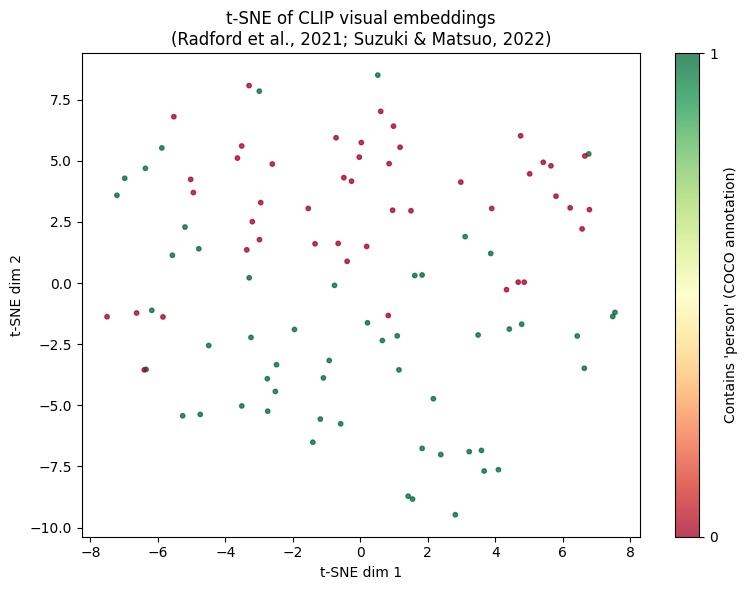

Saved: /content/drive/MyDrive/dissertation_final/results/week5_tsne_embeddings.png


In [ ]:
# CELL 9 - Running t-SNE embeddings

print('Running t-SNE (~2 min)')
n_samples  = min(500, len(img_embs))
idx        = np.random.choice(len(img_embs), n_samples, replace=False)
embs_sub   = img_embs[idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
proj = tsne.fit_transform(embs_sub)

has_person = np.array([
    1 if test_df.iloc[i]['image_id'] in cat_image_ids.get('person', set()) else 0
    for i in idx
])

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(proj[:,0], proj[:,1], c=has_person, cmap='RdYlGn', s=10, alpha=0.75)
plt.colorbar(sc, ax=ax, ticks=[0,1], label="Contains 'person' (COCO annotation)")
ax.set_title('t-SNE of CLIP visual embeddings\n(Radford et al., 2021; Suzuki & Matsuo, 2022)')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
out = f'{RESULTS_DIR}/week5_tsne_embeddings.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

In [ ]:
# CELL 10 - Embedding interpolation

print('Running embedding interpolation demo')
records = []
for pair_idx in range(3):
    idx_a, idx_b = np.random.choice(len(test_df), 2, replace=False)
    emb_a, emb_b = img_embs[idx_a], img_embs[idx_b]
    for step, alpha in enumerate(np.linspace(0, 1, 5)):
        emb     = (1-alpha)*emb_a + alpha*emb_b
        emb     = emb / np.linalg.norm(emb)
        sims    = img_embs @ emb
        nearest = int(np.argmax(sims))
        records.append({
            'pair': pair_idx, 'step': step, 'alpha': round(float(alpha), 2),
            'nearest_id': test_df.iloc[nearest]['image_id'],
            'nearest_caption': test_df.iloc[nearest]['captions'].split(' | ')[0],
            'similarity': round(float(sims[nearest]), 4),
        })
    print(f'  Pair {pair_idx+1}: {test_df.iloc[idx_a]["image_id"]} -> {test_df.iloc[idx_b]["image_id"]}')

interp_df = pd.DataFrame(records)
interp_df.to_csv(f'{RESULTS_DIR}/week5_interpolation.csv', index=False)
print(interp_df[['pair','alpha','nearest_caption']].to_string(index=False))

Running embedding interpolation demo
  Pair 1: 338219 -> 349184
  Pair 2: 50638 -> 543043
  Pair 3: 423123 -> 184324
 pair  alpha                                                 nearest_caption
    0   0.00              A couple of motorcycles parked next to each other.
    0   0.25              A couple of motorcycles parked next to each other.
    0   0.50              A couple of motorcycles parked next to each other.
    0   0.75           A woman sitting on top of a wooden bench near a park.
    0   1.00           A woman sitting on top of a wooden bench near a park.
    1   0.00 A boy carries a stuffed animal as he walks beside some flowers.
    1   0.25 A boy carries a stuffed animal as he walks beside some flowers.
    1   0.50 A boy carries a stuffed animal as he walks beside some flowers.
    1   0.75                   There is a red car parked next to an old bus.
    1   1.00                   There is a red car parked next to an old bus.
    2   0.00       A woman bending o

In [ ]:
# CELL 11 - COCO-grounded direction vectors

def compute_coco_direction(img_embeddings, df, category_name, cat_image_ids):
    if category_name not in cat_image_ids:
        print(f'Category {category_name} not found.')
        return None
    with_ids    = cat_image_ids[category_name]
    without_ids = set(df['image_id'].tolist()) - with_ids
    with_mask   = df['image_id'].isin(with_ids).values
    wo_mask     = df['image_id'].isin(without_ids).values
    if with_mask.sum() < 5 or wo_mask.sum() < 5:
        print(f'Insufficient samples for {category_name}.')
        return None
    direction = img_embeddings[with_mask].mean(0) - img_embeddings[wo_mask].mean(0)
    direction = direction / np.linalg.norm(direction)
    print(f'  Direction computed: {category_name} | WITH={with_mask.sum()} WITHOUT={wo_mask.sum()}')
    return direction

def steer_embedding(emb, direction, strength=STEER_STRENGTH):
    steered = emb + strength * direction
    return steered / np.linalg.norm(steered)

print('Computing COCO-grounded direction vectors')
directions = {}
for cat in ['person', 'car', 'dog', 'cat', 'chair']:
    d = compute_coco_direction(img_embs, test_df, cat, cat_image_ids)
    if d is not None:
        directions[cat] = d
print(f'\nDirections computed for: {list(directions.keys())}')

Computing COCO-grounded direction vectors
  Direction computed: person | WITH=54 WITHOUT=46
  Direction computed: car | WITH=12 WITHOUT=88
Insufficient samples for dog.
Category cat not found.
  Direction computed: chair | WITH=11 WITHOUT=89

Directions computed for: ['person', 'car', 'chair']


In [ ]:
# CELL 12 - Attribute steering demo

print('Running COCO-grounded attribute steering')
sample_df = test_df.sample(20, random_state=42).reset_index(drop=True)
records   = []

for cat_name, direction in directions.items():
    for i, (_, row) in enumerate(sample_df.iterrows()):
        orig_idx  = test_df.index[test_df['image_id'] == row['image_id']]
        if len(orig_idx) == 0: continue
        orig_emb    = img_embs[orig_idx[0]]
        steered_emb = steer_embedding(orig_emb, direction)
        orig_near   = int(np.argmax(img_embs @ orig_emb))
        steer_near  = int(np.argmax(img_embs @ steered_emb))
        records.append({
            'category_direction': f'-> {cat_name}',
            'image_id':           row['image_id'],
            'original_caption':   test_df.iloc[orig_near]['captions'].split(' | ')[0],
            'steered_caption':    test_df.iloc[steer_near]['captions'].split(' | ')[0],
            'caption_changed':    orig_near != steer_near,
            'moved_toward_cat':   test_df.iloc[steer_near]['image_id'] in cat_image_ids.get(cat_name, set()),
        })

steer_df = pd.DataFrame(records)
steer_df.to_csv(f'{RESULTS_DIR}/week5_attribute_steering.csv', index=False)
print('\nSteering results:')
print(steer_df.groupby('category_direction')[['caption_changed','moved_toward_cat']].mean().round(2).to_string())

Running COCO-grounded attribute steering

Steering results:
                    caption_changed  moved_toward_cat
category_direction                                   
-> car                          0.0              0.15
-> chair                        0.0              0.10
-> person                       0.0              0.60


In [ ]:
# CELL 13 - Final verification

print('='*55)
print('Week 5 — Final verification')
print('='*55)
for f in [f'{RESULTS_DIR}/week5_img_embeddings.npy',
          f'{RESULTS_DIR}/week5_txt_embeddings.npy',
          f'{RESULTS_DIR}/week5_tsne_embeddings.png',
          f'{RESULTS_DIR}/week5_interpolation.csv',
          f'{RESULTS_DIR}/week5_attribute_steering.csv']:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) if exists else 0
    print(f'  [{"OK" if exists else "MISSING"}] {os.path.basename(f):40s} {size:>10,} bytes')
print()
print('Week 5 complete. Next: week6_embedding_eval_colab.ipynb')
print(f'Directions available for week 6: {list(directions.keys())}')

Week 5 — Final verification
  [OK] week5_img_embeddings.npy                    204,928 bytes
  [OK] week5_txt_embeddings.npy                    204,928 bytes
  [OK] week5_tsne_embeddings.png                    81,665 bytes
  [OK] week5_interpolation.csv                       1,189 bytes
  [OK] week5_attribute_steering.csv                  8,304 bytes

Week 5 complete. Next: week6_embedding_eval_colab.ipynb
Directions available for week 6: ['person', 'car', 'chair']
